In [28]:
# Liesel
import liesel.model as lsl
import liesel.goose as gs

# Tensorflow
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

# Jax
import jax.numpy as jnp
import jax

# Plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Utils
import numpy as np
import pandas as pd
import datetime
import time
import json
import pickle
import os

In [29]:
# ====================
# 1. DATA LOADING 
# ====================
def load_camera_data(filepath):
    """Loads and preprocesses the camera dataset."""
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
    
    X_list, y_list, unit_indices = [], [], []
    n_alts = 5  # Canon, Sony, Nikon, Panasonic, Fuji
    
    for i, respondent in enumerate(raw_data):
        X_raw = np.array(respondent['X'])
        y_raw = np.array(respondent['y'])
        
        n_choice_occasions = len(y_raw)
        n_params = X_raw.shape[1]
        
        # Reshape X: (Obs, Alts, Params)
        X_reshaped = X_raw.reshape((n_choice_occasions, n_alts, n_params))
        
        # Adjust Y: 0-based indexing for Liesel/JAX Categorical
        y_adjusted = y_raw - 1
        
        X_list.append(X_reshaped)
        y_list.append(y_adjusted)
        unit_indices.extend([i] * n_choice_occasions)

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "unit_idx": jnp.array(unit_indices),
        "n_units": len(raw_data),
        "n_params": X_list[0].shape[2]
    }

print("Loading data...")
data_dict = load_camera_data("camera_data.json")

k_dim = int(data_dict["n_params"])
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]

print(f"Data Loaded: {data_dict['n_units']} units, {k_dim} parameters.")
print(f"Total Observations: {data_dict['y'].shape[0]}")

Loading data...
Data Loaded: 332 units, 10 parameters.
Total Observations: 5312


In [30]:
# ====================
# 2. FACTORY FUNCTIONS
# ====================
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, 
        scale_tril=scale_tril, 
        input_output_cholesky=True, 
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [31]:
# ====================
# 3. MODEL BUILDING
# ====================
def build_hmnl_camera_model(data_dict, A_val=0.01):
    """Constructs the Hierarchical MNL model using Liesel (No Demographics)."""
    k_dim = int(data_dict["n_params"]) 
    n_units = int(data_dict["n_units"])

    nu_val = float(k_dim + 3)
    V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
    Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)

    # Unobserved Heterogeneity Covariance Matrix
    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.eye(k_dim),
        distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
        name="sigma_inv_chol"
    )

    sigma_inv_chol_latent = sigma_inv_chol.transform(
        tfb.FillScaleTriL(), 
        name="sigma_inv_chol_latent"
    )

    mu_prec_factor = lsl.Var.new_calc(
        lambda L: jnp.sqrt(A_val) * L, 
        L=sigma_inv_chol, 
        name="mu_prec_factor"
    )

    # Baseline/Global Mean for all households
    mu = lsl.Var.new_param(
        value=jnp.zeros(k_dim),
        distribution=lsl.Dist(
            make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=mu_prec_factor
        ),
        name="mu"
    )

    # Unit-level coefficients
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, k_dim)),
        distribution=lsl.Dist(make_mvn_precision, loc=mu, precision_factor=sigma_inv_chol),
        name="beta_i"
    )

    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

    beta_expanded = lsl.Var.new_calc(lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded")
    logits = lsl.Var.new_calc(lambda x, b: jnp.einsum("nij,nj->ni", x, b), x=X_var, b=beta_expanded, name="logits")

    y_var = lsl.Var.new_obs(data_dict["y"], distribution=lsl.Dist(tfd.Categorical, logits=logits), name="y")

    return lsl.Model([y_var])


def run_inference(model, chains=4, warmup=1000, posterior=2000, seed=123):
    """Sets up the MCMC engine and samples from the model."""
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    # Note: We now target 'mu' instead of 'Delta'
    eb.add_kernel(gs.NUTSKernel(["mu"])) 
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting Sampling...")
    engine = eb.build()
    engine.sample_all_epochs()

    results = engine.get_results()
    samples = results.get_posterior_samples()
    return results, samples

In [32]:
# ====================
# 4. RUN SAMPLING
# ====================
start_time = time.time()

print("Building model...")
model = build_hmnl_camera_model(data_dict)

# MCMC Configuration
n_chains = 1
n_warmup = 1000
n_posterior = 10000
results, samples = run_inference(model, chains=n_chains, warmup=n_warmup, posterior=n_posterior)

end_time = time.time()
formatted_time = str(datetime.timedelta(seconds=int(end_time - start_time)))
print(f"Sampling finished in {formatted_time} (H:M:S)")

# Save samples
pkl_filename = "liesel_posterior_samples_camera.pkl" 
print(f"Saving samples to {pkl_filename}...")
with open(pkl_filename, "wb") as f:
    pickle.dump({"results": results, "samples": samples}, f)
print("Samples saved successfully!")

c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Building model...
Starting Sampling...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:16<00:00,  5.54s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 9 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 3 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 313.69chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 3 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 / 25 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - IN

Sampling finished in 0:17:19 (H:M:S)
Saving samples to liesel_posterior_samples_camera.pkl...
Samples saved successfully!


In [33]:
# ====================
# 5. POSTERIOR TABLES
# ====================
def generate_posterior_tables(samples, param_names):
    """Calculates posterior means and stds for Mu and the Covariance matrix."""
    k_dim = len(param_names)

    # 1. Posterior distribution of Mu (Baseline Means)
    mu_draws = samples["mu"].reshape(-1, k_dim)
    mu_mean = np.mean(mu_draws, axis=0)
    mu_std = np.std(mu_draws, axis=0)

    mu_df = pd.DataFrame({
        "Parameter": param_names,
        "Posterior Mean": mu_mean,
        "Std. Dev": mu_std
    }).set_index("Parameter")

    # 2. Covariance / Correlation of Betas
    latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
    bijector = tfb.FillScaleTriL()

    v_latent_to_cov = jax.vmap(lambda v: jnp.linalg.inv(bijector.forward(v) @ bijector.forward(v).T))
    cov_draws = np.array(v_latent_to_cov(latent_samples)) 

    std_draws = np.sqrt(np.diagonal(cov_draws, axis1=1, axis2=2))
    outer_stds = std_draws[:, :, None] * std_draws[:, None, :]
    corr_draws = cov_draws / outer_stds

    std_mean, std_sd = np.mean(std_draws, axis=0), np.std(std_draws, axis=0)
    corr_mean, corr_sd = np.mean(corr_draws, axis=0), np.std(corr_draws, axis=0)

    cov_corr_df = pd.DataFrame(index=param_names, columns=param_names)

    for i in range(k_dim):
        for j in range(k_dim):
            if i == j:
                cov_corr_df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
            elif j > i:
                cov_corr_df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
            else:
                cov_corr_df.iloc[i, j] = ""

    return mu_df, cov_corr_df

# Generate and display tables
df_mu, df_cov_corr = generate_posterior_tables(samples, param_names)

print("=== Posterior distribution of Mu (Global Base Utilities) ===")
display(df_mu)

print("\n=== Correlations and standard deviations of betas ===")
display(df_cov_corr)

=== Posterior distribution of Mu (Global Base Utilities) ===


,Posterior Mean,Std. Dev
Parameter,,
Canon,2.007713,0.367135
Sony,1.577449,0.382264
Nikon,1.703256,0.373087
Panasonic,1.175954,0.372112
Pixels,1.432275,0.138461
Zoom,1.757246,0.139631
Video,1.333425,0.113814
Swivel,0.767548,0.109786
Wifi,1.210306,0.121778



=== Correlations and standard deviations of betas ===


,Canon,Sony,Nikon,Panasonic,Pixels,Zoom,Video,Swivel,Wifi,Price
Canon,5.76 (0.35),0.96 (0.01),0.97 (0.01),0.96 (0.01),-0.58 (0.06),-0.50 (0.07),-0.28 (0.09),-0.19 (0.09),-0.29 (0.08),-0.60 (0.05)
Sony,,6.03 (0.36),0.96 (0.01),0.98 (0.01),-0.52 (0.06),-0.49 (0.07),-0.28 (0.09),-0.17 (0.09),-0.24 (0.08),-0.61 (0.05)
Nikon,,,5.95 (0.35),0.96 (0.01),-0.56 (0.06),-0.54 (0.06),-0.29 (0.09),-0.19 (0.09),-0.27 (0.08),-0.58 (0.05)
Panasonic,,,,5.92 (0.35),-0.53 (0.06),-0.48 (0.07),-0.24 (0.09),-0.20 (0.09),-0.24 (0.08),-0.61 (0.05)
Pixels,,,,,1.96 (0.13),0.41 (0.07),0.09 (0.09),0.03 (0.09),-0.04 (0.09),0.39 (0.07)
Zoom,,,,,,1.94 (0.13),0.08 (0.09),-0.05 (0.09),0.17 (0.09),0.20 (0.08)
Video,,,,,,,1.40 (0.11),0.16 (0.09),0.11 (0.10),0.08 (0.09)
Swivel,,,,,,,,1.45 (0.11),0.14 (0.10),0.09 (0.09)
Wifi,,,,,,,,,1.60 (0.12),0.04 (0.09)
Price,,,,,,,,,,2.60 (0.16)


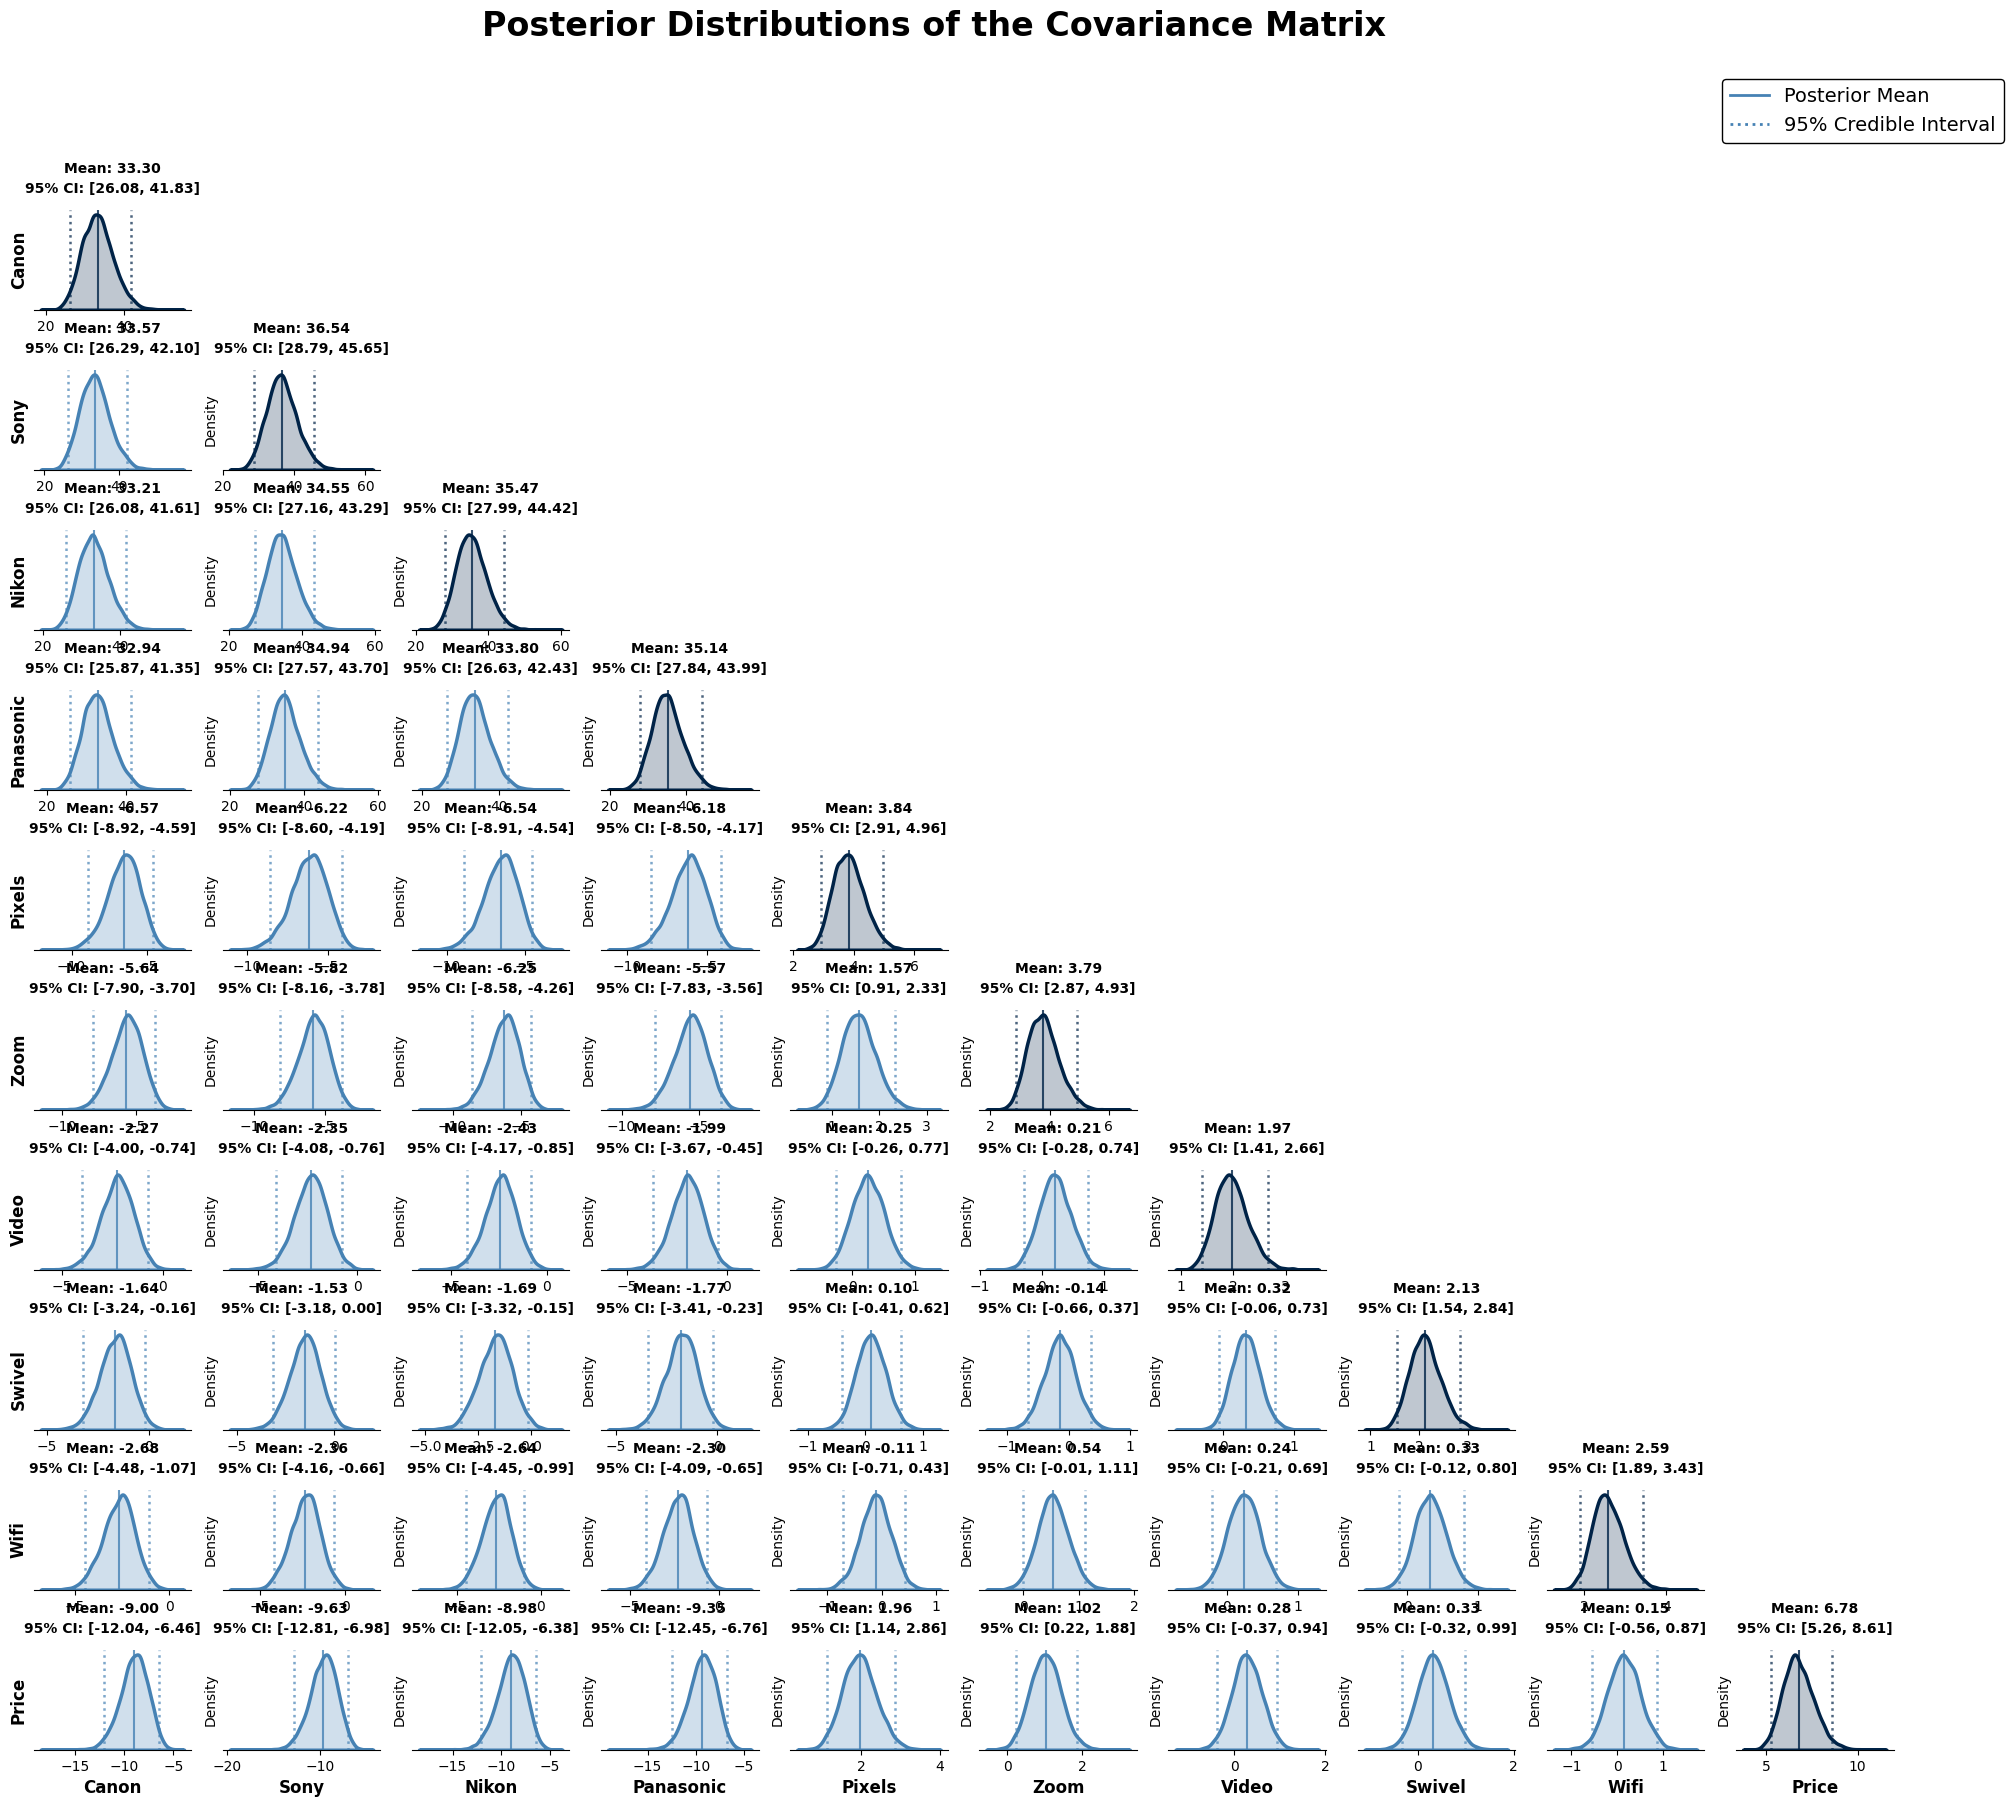


=== Global Mu Trace Plots ===


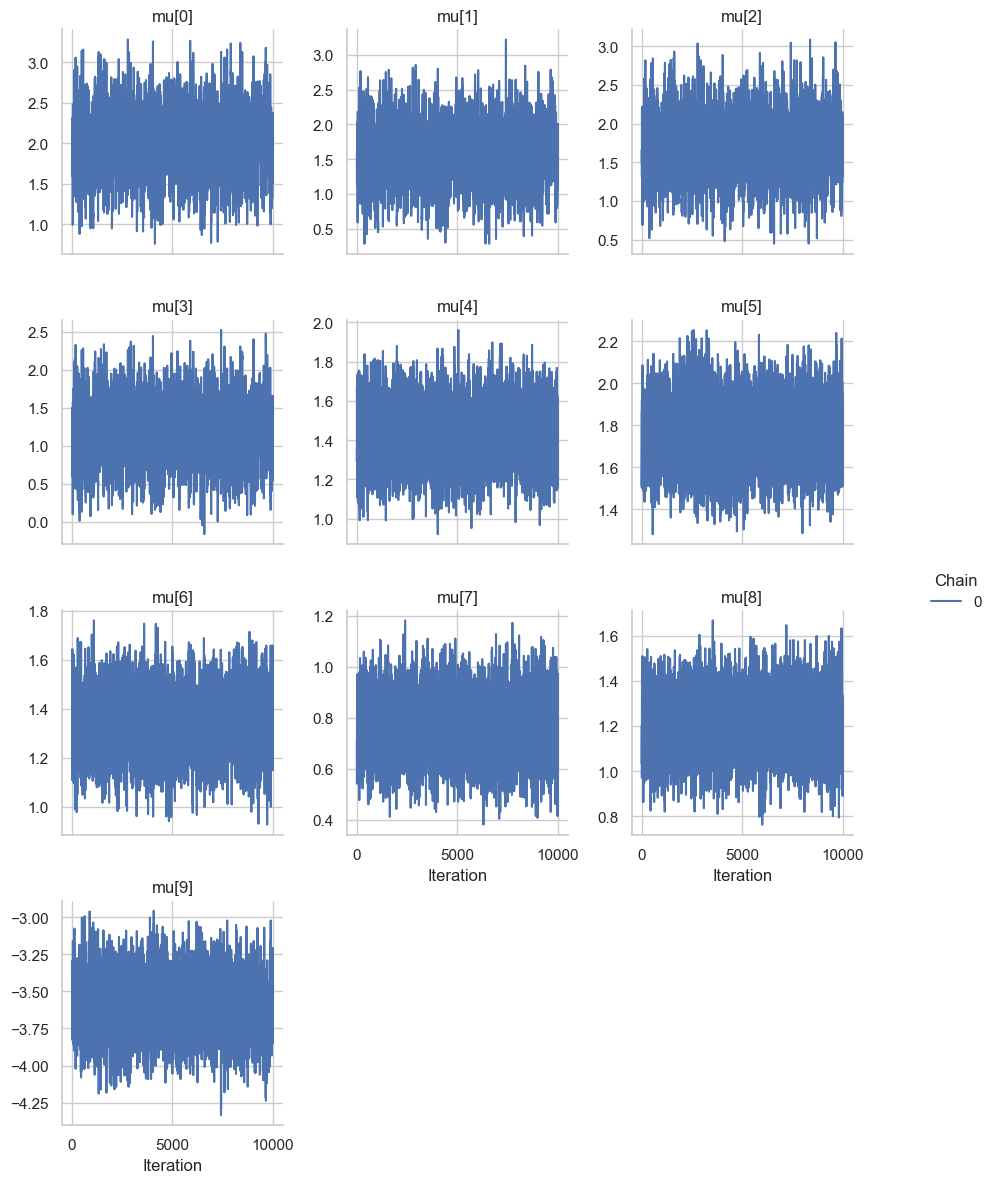


=== Detailed Mu Parameter Diagnostics ===
Detailed Diagnostics: mu[0]


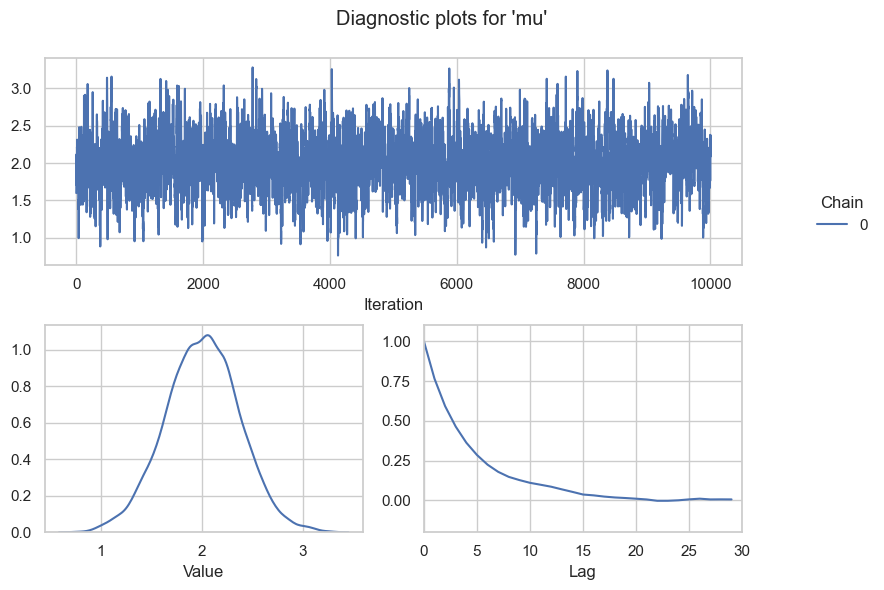

Detailed Diagnostics: mu[1]


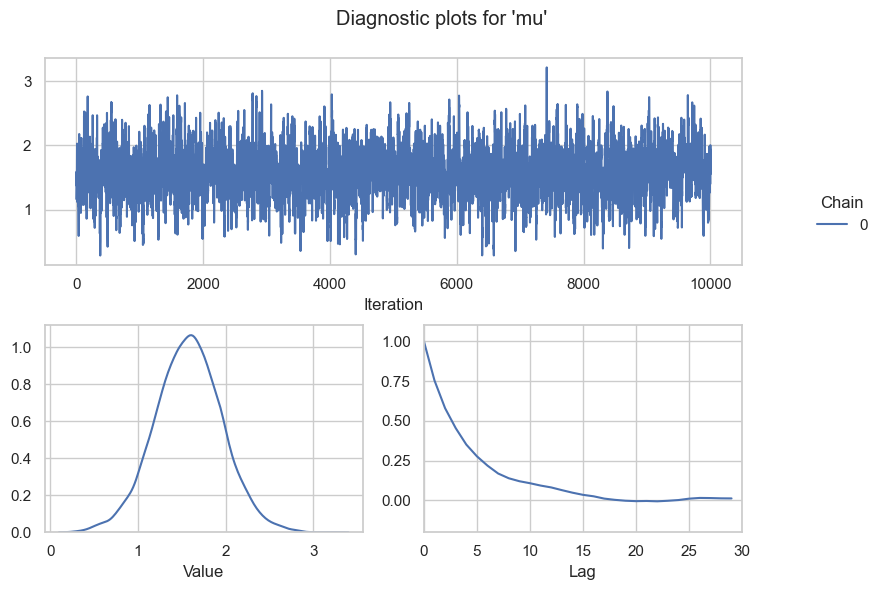

Detailed Diagnostics: mu[2]


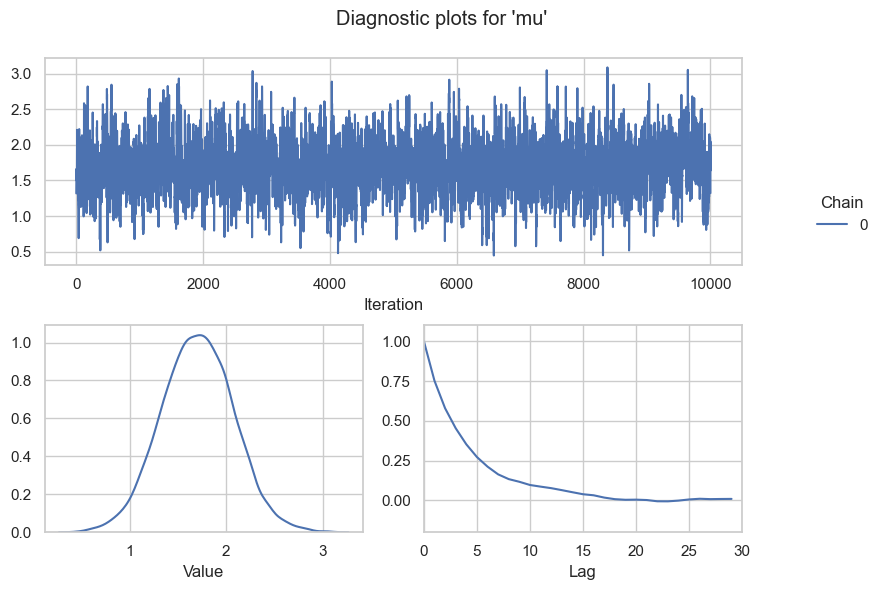

Detailed Diagnostics: mu[3]


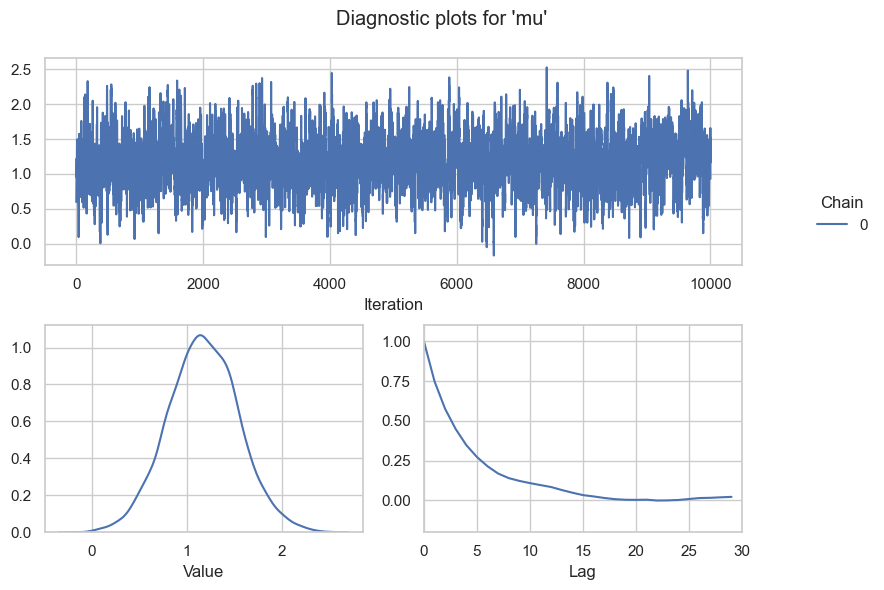

Detailed Diagnostics: mu[4]


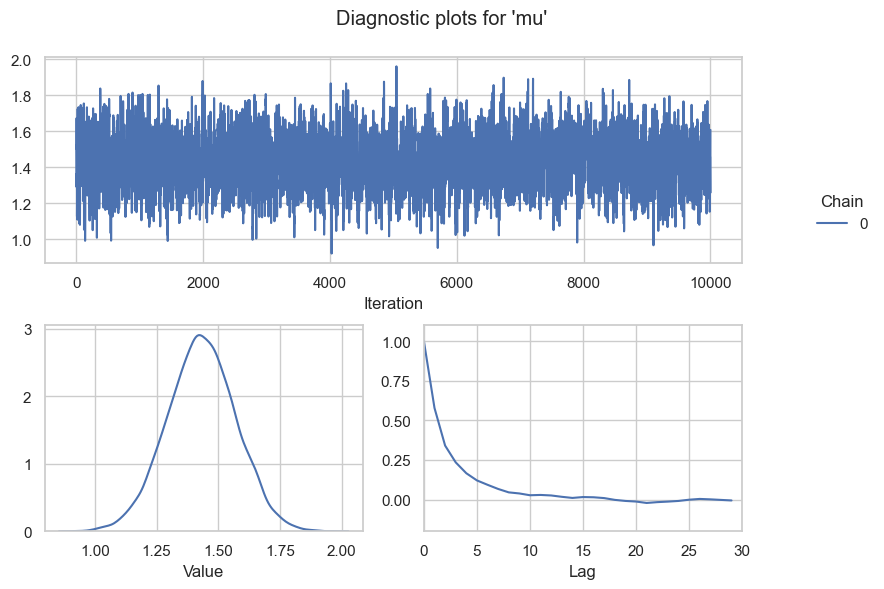

In [34]:
# ==========================================
# 6. ANALYTICS & DIAGNOSTICS PLOTS
# ==========================================

def plot_final_covariance_complete(sigma_samples, param_names, true_matrix=None, empirical_matrix=None):
    n_dim = sigma_samples.shape[-1]
    
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(24, 20))
    
    # Color Palette
    diag_color      = "#002347"  
    off_diag_color  = "#4682B4"  
    true_val_color  = "#D62728"  
    emp_val_color   = "#2CA02C"  

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # Lower Triangular Logic
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = sigma_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_val:.2f}")
            
            if empirical_matrix is not None:
                emp_val = empirical_matrix[i, j]
                ax.axvline(emp_val, color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {emp_val:.2f}")

            stats_str = " | ".join(title_parts)
            title_str = f"{stats_str}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1:
                ax.set_xlabel(param_names[j], fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(param_names[i], fontsize=12, fontweight='bold')

    # Floating Legend
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
    ]
    if true_matrix is not None:
        legend_elements.append(Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'))
    if empirical_matrix is not None:
        legend_elements.append(Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Data Covariance'))
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.95, 0.95), 
               fontsize=14, frameon=True, edgecolor='black', framealpha=1, fancybox=True)

    plt.suptitle("Posterior Distributions of the Covariance Matrix", fontsize=24, y=0.98, fontweight='bold')
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()


# Extract Sigma Samples
latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
bijector = tfb.FillScaleTriL()
def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

v_latent_to_sigma = jax.vmap(latent_to_sigma)
sigma_samples = np.array(v_latent_to_sigma(latent_samples))

# Plot the large 10x10 Matrix
plot_final_covariance_complete(sigma_samples, param_names)

# =======================
# MCMC TRACE DIAGNOSTICS
# =======================
def plot_detailed_param(results_dict, param_name, param_indices):
    """Plot detailed diagnostics for a parameter."""
    if isinstance(param_indices, int):
        param_indices = [param_indices]
    for idx in param_indices:
        print(f"Detailed Diagnostics: {param_name}[{idx}]")
        gs.plot_param(results_dict, param_name, param_index=idx)
        plt.show()

print("\n=== Global Mu Trace Plots ===")
gs.plot_trace(results, "mu")
plt.show()

print("\n=== Detailed Mu Parameter Diagnostics ===")
# Plot detailed diagnostics for the first 5 parameters to avoid overwhelming the notebook
plot_detailed_param(results, "mu", param_indices=range(5))
plt.show()